# 1.Feature Engineering

This notebook contain Feature Engineering in 3 aspects for our arrest prediction:

- Temporal feature
- Spatial(location type) feature
- Crime Type Mapping for Chicago dataset 

## Load Dataset

In [37]:
import pandas as pd
import os

nb_dir = os.getcwd()

project_root = os.path.abspath(os.path.join(nb_dir, ".."))

folder_path = os.path.join(project_root, "data")
file_list = [
    os.path.join(folder_path, f"train_{year}.csv")
    for year in range(2015, 2025)
]

df_chicago = pd.concat([pd.read_csv(f) for f in file_list], ignore_index=True)  

print(df_chicago.shape)


(2755736, 22)


## Spatial Feature Engineering

### Mapping Standard for Location Type

This document provides a mapping standard for the location type feature in datasets. The goal is to create a common set of categories that can be used across different datasets to ensure consistency and comparability.

| Common Category         | Chicago Dataset (Location Description) | 
|-------------------------|--------------------------------|
| **Residence**          | RESIDENCE, HOUSE, APARTMENT, RESIDENCE - YARD (FRONT / BACK), RESIDENCE - GARAGE, RESIDENCE - PORCH / HALLWAY, DRIVEWAY - RESIDENTIAL | 
| **Street/Outdoor**     | ALLEY, STREET, SIDEWALK, VACANT LOT / LAND, PARK PROPERTY, BRIDGE, HIGHWAY / EXPRESSWAY, LAKEFRONT / WATERFRONT / RIVERBANK |
| **Transportation Hub**  | CTA PLATFORM, CTA BUS, CTA TRAIN, CTA STATION, AIRPORT TERMINAL LOWER LEVEL - SECURE AREA, AIRPORT PARKING LOT, AIRPORT TERMINAL UPPER LEVEL - SECURE AREA |
| **Retail/Commercial**  | SMALL RETAIL STORE, GROCERY FOOD STORE, DEPARTMENT STORE, DRUG STORE, CONVENIENCE STORE, CURRENCY EXCHANGE, BANK, PAWN SHOP, LIQUOR STORE |
| **Entertainment**      | BAR OR TAVERN, TAVERN / LIQUOR STORE, MOVIE HOUSE / THEATER, SPORTS ARENA / STADIUM, BOWLING ALLEY |
| **Government/Public**  | GOVERNMENT BUILDING / PROPERTY, POLICE FACILITY, FIRE STATION, SCHOOL - PUBLIC BUILDING, LIBRARY | 
| **Medical Facility**   | HOSPITAL BUILDING / GROUNDS, MEDICAL / DENTAL OFFICE, NURSING / RETIREMENT HOME, ANIMAL HOSPITAL |
| **Workplace/Office**   | COMMERCIAL / BUSINESS OFFICE, FACTORY / MANUFACTURING BUILDING | 
| **Parking Lot**        | PARKING LOT / GARAGE (NON RESIDENTIAL), CHA PARKING LOT / GROUNDS | 
| **Unknown/Other**      | OTHER (SPECIFY), ATM (AUTOMATIC TELLER MACHINE), COIN OPERATED MACHINE | 

### Location mapping for Chicago Crime Dataset
The `key` i s from "Location Description" column in the dataset. The `value` is the corresponding location type. The mapping is based on the description of the location in the dataset and common sense knowledge about the types of locations.

In [38]:
# Create a mapping dictionary
mapping1 = {
    "RESIDENCE - YARD (FRONT / BACK)": "Residence",
    "APARTMENT": "Residence",
    "HOUSE": "Residence",
    "STREET": "Street/Outdoor",
    "ALLEY": "Street/Outdoor",
    "SIDEWALK": "Street/Outdoor",
    "VACANT LOT / LAND": "Street/Outdoor",
    "PARK PROPERTY": "Street/Outdoor",
    "CTA PLATFORM": "Transportation Hub",
    "CTA BUS": "Transportation Hub",
    "CTA TRAIN": "Transportation Hub",
    "AIRPORT TERMINAL LOWER LEVEL - SECURE AREA": "Transportation Hub",
    "GROCERY FOOD STORE": "Retail/Commercial",
    "DRUG STORE": "Retail/Commercial",
    "DEPARTMENT STORE": "Retail/Commercial",
    "BANK": "Retail/Commercial",
    "BAR OR TAVERN": "Entertainment",
    "MOVIE HOUSE / THEATER": "Entertainment",
    "SPORTS ARENA / STADIUM": "Entertainment",
    "GOVERNMENT BUILDING / PROPERTY": "Government/Public",
    "POLICE FACILITY": "Government/Public",
    "HOSPITAL BUILDING / GROUNDS": "Medical Facility",
    "COMMERCIAL / BUSINESS OFFICE": "Workplace/Office",
    "FACTORY / MANUFACTURING BUILDING": "Workplace/Office",
    "PARKING LOT / GARAGE (NON RESIDENTIAL)": "Parking Lot",
    "OTHER (SPECIFY)": "Unknown/Other"
}

# Apply the mapping
df_chicago["unified_location_category"] = df_chicago["Location Description"].map(mapping1).fillna("Unknown/Other")

# Save the processed data
df_chicago.to_csv("df_chicago_mapped.csv", index=False)


# Display the first few rows
print(df_chicago.head())


         ID Case Number                 Date                     Block  IUCR  \
0  10460641    HZ199559  2015-12-31 23:59:00        015XX N KEDZIE AVE  0890   
1  10365064    HZ100370  2015-12-31 23:59:00       075XX S EMERALD AVE  1320   
2  10364662    HZ100006  2015-12-31 23:55:00  079XX S STONY ISLAND AVE  0430   
3  10364740    HZ100010  2015-12-31 23:50:00         024XX W FARGO AVE  0820   
4  10364683    HZ100002  2015-12-31 23:50:00          037XX N CLARK ST  0460   

      Primary Type                    Description     Location Description  \
0            THEFT                  FROM BUILDING  RESIDENCE PORCH/HALLWAY   
1  CRIMINAL DAMAGE                     TO VEHICLE                   STREET   
2          BATTERY  AGGRAVATED: OTHER DANG WEAPON                   STREET   
3            THEFT                 $500 AND UNDER                APARTMENT   
4          BATTERY                         SIMPLE                 SIDEWALK   

   Arrest  Domestic  ...  Community Area  FBI Code

### Create unified location type encoding number for datasets
The `key` is the updated location type from previous processing step. The `value` is the corresponding encoding number. 


| **common_category**    | **UNIFIED_LOCATION_CODE** |
|-----------------------|------------------------|
| Residence            | 1  |
| Street/Outdoor      | 2  |
| Transportation Hub  | 3  |
| Retail/Commercial   | 4  |
| Entertainment       | 5  |
| Government/Public   | 6  |
| Medical Facility    | 7  |
| Workplace/Office    | 8  |
| Parking Lot        | 9  |
| Unknown/Other      | 10 |


In [39]:
# Define UNIFIED_LOCATION_CODE mapping
unified_location_mapping = {
    "Residence": 1,
    "Street/Outdoor": 2,
    "Transportation Hub": 3,
    "Retail/Commercial": 4,
    "Entertainment": 5,
    "Government/Public": 6,
    "Medical Facility": 7,
    "Workplace/Office": 8,
    "Parking Lot": 9,
    "Unknown/Other": 10
}

In [40]:
# Read and process dataset1
df_chicago["UNIFIED_LOCATION_CODE"] = df_chicago["unified_location_category"].map(unified_location_mapping)
df_chicago.to_csv("df_chicago_final.csv", index=False)
print(df_chicago.head())

         ID Case Number                 Date                     Block  IUCR  \
0  10460641    HZ199559  2015-12-31 23:59:00        015XX N KEDZIE AVE  0890   
1  10365064    HZ100370  2015-12-31 23:59:00       075XX S EMERALD AVE  1320   
2  10364662    HZ100006  2015-12-31 23:55:00  079XX S STONY ISLAND AVE  0430   
3  10364740    HZ100010  2015-12-31 23:50:00         024XX W FARGO AVE  0820   
4  10364683    HZ100002  2015-12-31 23:50:00          037XX N CLARK ST  0460   

      Primary Type                    Description     Location Description  \
0            THEFT                  FROM BUILDING  RESIDENCE PORCH/HALLWAY   
1  CRIMINAL DAMAGE                     TO VEHICLE                   STREET   
2          BATTERY  AGGRAVATED: OTHER DANG WEAPON                   STREET   
3            THEFT                 $500 AND UNDER                APARTMENT   
4          BATTERY                         SIMPLE                 SIDEWALK   

   Arrest  Domestic  ...  FBI Code  X Coordinate  

## Temporal Feature Engineering

In [41]:
df_chicago['date'] = pd.to_datetime(df_chicago['Date'], errors='coerce')

### Basic Temporal Feature

- month – the month of the incident
- day – the day in month of the incident
- hour – the hour of the incident
- weekday – the day of the week
- is_weekend – flag for Saturday/Sunday

In [42]:
def extractBasicTimeFeature(df):
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df['hour'] = df['date'].dt.hour
    df['weekday'] = df['date'].dt.weekday  # 0=Monday, 6=Sunday
    df['is_weekend'] = df['weekday'].isin([5, 6]).astype(int) # if weekend

    return df

In [43]:
df_chicago = extractBasicTimeFeature(df_chicago)
df_chicago.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Longitude,Location,unified_location_category,UNIFIED_LOCATION_CODE,date,month,day,hour,weekday,is_weekend
0,10460641,HZ199559,2015-12-31 23:59:00,015XX N KEDZIE AVE,0890,THEFT,FROM BUILDING,RESIDENCE PORCH/HALLWAY,False,False,...,NaN,NaN,Unknown/Other,10,2015-12-31 23:59:00,12,31,23,3,0
1,10365064,HZ100370,2015-12-31 23:59:00,075XX S EMERALD AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,...,-87.642993,"(41.757366519, -87.642992854)",Street/Outdoor,2,2015-12-31 23:59:00,12,31,23,3,0
2,10364662,HZ100006,2015-12-31 23:55:00,079XX S STONY ISLAND AVE,0430,BATTERY,AGGRAVATED: OTHER DANG WEAPON,STREET,False,False,...,-87.585822,"(41.751270452, -87.585822373)",Street/Outdoor,2,2015-12-31 23:55:00,12,31,23,3,0
3,10364740,HZ100010,2015-12-31 23:50:00,024XX W FARGO AVE,0820,THEFT,$500 AND UNDER,APARTMENT,False,False,...,-87.690709,"(42.016804165, -87.690708662)",Residence,1,2015-12-31 23:50:00,12,31,23,3,0
4,10364683,HZ100002,2015-12-31 23:50:00,037XX N CLARK ST,0460,BATTERY,SIMPLE,SIDEWALK,True,False,...,-87.658635,"(41.949837364, -87.658635101)",Street/Outdoor,2,2015-12-31 23:50:00,12,31,23,3,0


### Holiday Feature Extraction

Added a binary flag indicating whether the incident occurred on a holiday.

In [44]:
import holidays

In [45]:
def extractHolidayFeature(df):
    us_holidays = holidays.US()
    df['is_holiday'] = df['date'].dt.date.apply(lambda x: 1 if x in us_holidays else 0)

    return df

In [46]:
df_chicago = extractHolidayFeature(df_chicago)
df_chicago.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Location,unified_location_category,UNIFIED_LOCATION_CODE,date,month,day,hour,weekday,is_weekend,is_holiday
0,10460641,HZ199559,2015-12-31 23:59:00,015XX N KEDZIE AVE,0890,THEFT,FROM BUILDING,RESIDENCE PORCH/HALLWAY,False,False,...,NaN,Unknown/Other,10,2015-12-31 23:59:00,12,31,23,3,0,0
1,10365064,HZ100370,2015-12-31 23:59:00,075XX S EMERALD AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,...,"(41.757366519, -87.642992854)",Street/Outdoor,2,2015-12-31 23:59:00,12,31,23,3,0,0
2,10364662,HZ100006,2015-12-31 23:55:00,079XX S STONY ISLAND AVE,0430,BATTERY,AGGRAVATED: OTHER DANG WEAPON,STREET,False,False,...,"(41.751270452, -87.585822373)",Street/Outdoor,2,2015-12-31 23:55:00,12,31,23,3,0,0
3,10364740,HZ100010,2015-12-31 23:50:00,024XX W FARGO AVE,0820,THEFT,$500 AND UNDER,APARTMENT,False,False,...,"(42.016804165, -87.690708662)",Residence,1,2015-12-31 23:50:00,12,31,23,3,0,0
4,10364683,HZ100002,2015-12-31 23:50:00,037XX N CLARK ST,0460,BATTERY,SIMPLE,SIDEWALK,True,False,...,"(41.949837364, -87.658635101)",Street/Outdoor,2,2015-12-31 23:50:00,12,31,23,3,0,0


## Crime Type Mapping for Chicago dataset 

In [47]:
crime_mapping = {
    'THEFT': ('Property', 'Larceny/Theft Offenses'),
    'BATTERY': ('Person', 'Assault Offenses'),
    'CRIMINAL DAMAGE': ('Property', 'Destruction/Damage/Vandalism of Property'),
    'ASSAULT': ('Person', 'Assault Offenses'),
    'MOTOR VEHICLE THEFT': ('Property', 'Larceny/Theft Offenses'),
    'DECEPTIVE PRACTICE': ('Property', 'Fraud Offenses'),
    'OTHER OFFENSE': ('Society', 'Other Offenses'),
    'ROBBERY': ('Property', 'Robbery'),
    'WEAPONS VIOLATION': ('Society', 'Weapon Law Violations'),
    'BURGLARY': ('Property', 'Burglary/Breaking & Entering'),
    'NARCOTICS': ('Society', 'Drug/Narcotic Offenses'),
    'CRIMINAL TRESPASS': ('Society', 'Trespass of Real Property'),
    'OFFENSE INVOLVING CHILDREN': ('Person', 'Other Offenses'),
    'CRIMINAL SEXUAL ASSAULT': ('Person', 'Sex Offenses'),
    'SEX OFFENSE': ('Person', 'Sex Offenses'),
    'PUBLIC PEACE VIOLATION': ('Society', 'Curfew/Loitering/Vagrancy Violations'),
    'HOMICIDE': ('Person', 'Homicide Offenses'),
    'INTERFERENCE WITH PUBLIC OFFICER': ('Society', 'Bribery'),
    'ARSON': ('Property', 'Arson'),
    'STALKING': ('Person', 'Other Offenses'),
    'PROSTITUTION': ('Society', 'Prostitution Offenses'),
    'LIQUOR LAW VIOLATION': ('Society', 'Liquor Law Violations'),
    'CONCEALED CARRY LICENSE VIOLATION': ('Society', 'Weapon Law Violations'),
    'INTIMIDATION': ('Person', 'Assault Offenses'),
    'KIDNAPPING': ('Person', 'Kidnapping/Abduction'),
    'OBSCENITY': ('Society', 'Pornography/Obscene Material'),
    'GAMBLING': ('Society', 'Gambling Offenses'),
    'HUMAN TRAFFICKING': ('Person', 'Human Trafficking'),
    'PUBLIC INDECENCY': ('Society', 'Disorderly Conduct'),
    'OTHER NARCOTIC VIOLATION': ('Society', 'Drug/Narcotic Offenses'),
    'NON-CRIMINAL': ('Not a Crime', 'Other Offenses')
}

# Apply mapping
df_chicago[['crime_against', 'offense_category_name']] = df_chicago['Primary Type'].map(crime_mapping).apply(pd.Series)


In [48]:
df_chicago.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,UNIFIED_LOCATION_CODE,date,month,day,hour,weekday,is_weekend,is_holiday,crime_against,offense_category_name
0,10460641,HZ199559,2015-12-31 23:59:00,015XX N KEDZIE AVE,0890,THEFT,FROM BUILDING,RESIDENCE PORCH/HALLWAY,False,False,...,10,2015-12-31 23:59:00,12,31,23,3,0,0,Property,Larceny/Theft Offenses
1,10365064,HZ100370,2015-12-31 23:59:00,075XX S EMERALD AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,...,2,2015-12-31 23:59:00,12,31,23,3,0,0,Property,Destruction/Damage/Vandalism of Property
2,10364662,HZ100006,2015-12-31 23:55:00,079XX S STONY ISLAND AVE,0430,BATTERY,AGGRAVATED: OTHER DANG WEAPON,STREET,False,False,...,2,2015-12-31 23:55:00,12,31,23,3,0,0,Person,Assault Offenses
3,10364740,HZ100010,2015-12-31 23:50:00,024XX W FARGO AVE,0820,THEFT,$500 AND UNDER,APARTMENT,False,False,...,1,2015-12-31 23:50:00,12,31,23,3,0,0,Property,Larceny/Theft Offenses
4,10364683,HZ100002,2015-12-31 23:50:00,037XX N CLARK ST,0460,BATTERY,SIMPLE,SIDEWALK,True,False,...,2,2015-12-31 23:50:00,12,31,23,3,0,0,Person,Assault Offenses


In [49]:
df_chicago.to_csv("Chicago_AfterFeatureEngineering.csv", index=False)

data reading

In [2]:
import pandas as pd

df = pd.read_csv("Chicago_AfterFeatureEngineering.csv")
df.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,UNIFIED_LOCATION_CODE,date,month,day,hour,weekday,is_weekend,is_holiday,crime_against,offense_category_name
0,10460641,HZ199559,2015-12-31 23:59:00,015XX N KEDZIE AVE,0890,THEFT,FROM BUILDING,RESIDENCE PORCH/HALLWAY,False,False,...,10,2015-12-31 23:59:00,12,31,23,3,0,0,Property,Larceny/Theft Offenses
1,10365064,HZ100370,2015-12-31 23:59:00,075XX S EMERALD AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,...,2,2015-12-31 23:59:00,12,31,23,3,0,0,Property,Destruction/Damage/Vandalism of Property
2,10364662,HZ100006,2015-12-31 23:55:00,079XX S STONY ISLAND AVE,0430,BATTERY,AGGRAVATED: OTHER DANG WEAPON,STREET,False,False,...,2,2015-12-31 23:55:00,12,31,23,3,0,0,Person,Assault Offenses
3,10364740,HZ100010,2015-12-31 23:50:00,024XX W FARGO AVE,0820,THEFT,$500 AND UNDER,APARTMENT,False,False,...,1,2015-12-31 23:50:00,12,31,23,3,0,0,Property,Larceny/Theft Offenses
4,10364683,HZ100002,2015-12-31 23:50:00,037XX N CLARK ST,0460,BATTERY,SIMPLE,SIDEWALK,True,False,...,2,2015-12-31 23:50:00,12,31,23,3,0,0,Person,Assault Offenses


In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split

print(df.columns.tolist())

feature_cols = [
    'UNIFIED_LOCATION_CODE',
    'month',
    'day',
    'hour',
    'weekday',
    'is_weekend',
    'is_holiday',
    'crime_against',
    'offense_category_name'
]

# define x and y
X = df[feature_cols]
y = df['Arrest'].astype(int)

print(X.head())
print(X.dtypes)
print(X.shape)
print(X.isnull().sum())
print(y.isnull().sum())

# encode
X_encoded = pd.get_dummies(
    X,
    columns=['crime_against', 'offense_category_name'],
    drop_first=False
)
print(X_encoded.head())
print(X_encoded.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

['ID', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type', 'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code', 'X Coordinate', 'Y Coordinate', 'Year', 'Updated On', 'Latitude', 'Longitude', 'Location', 'unified_location_category', 'UNIFIED_LOCATION_CODE', 'date', 'month', 'day', 'hour', 'weekday', 'is_weekend', 'is_holiday', 'crime_against', 'offense_category_name']
   UNIFIED_LOCATION_CODE  month  day  hour  weekday  is_weekend  is_holiday  \
0                     10     12   31    23        3           0           0   
1                      2     12   31    23        3           0           0   
2                      2     12   31    23        3           0           0   
3                      1     12   31    23        3           0           0   
4                      2     12   31    23        3           0           0   

  crime_against                     offense_category_name  
0      Property          

# 2.Modeling Strategy
The project adopts a multi-model classification strategy, with model comparison as the central focus.

To emphasize modeling as the core of the assignment, four classification models were implemented and compared:

1.Logistic Regression
2.Decision Tree
3.Random Forest
4.Gradient Boosting

Logistic Regression served as a baseline model. Decision Tree was used to capture nonlinear decision rules. Random Forest provided an ensemble-tree benchmark, while Gradient Boosting tested a boosting-based alternative. This modeling strategy allowed a more meaningful comparison of model behavior and predictive suitability for the arrest prediction task.

2.1.Logistic Regression

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)


lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

y_prob = lr_model.predict_proba(X_test)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nAUC-ROC:")
print(roc_auc_score(y_test, y_prob))

c:\python\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Confusion Matrix:
[[359679  95329]
 [ 33951  62189]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.79      0.85    455008
           1       0.39      0.65      0.49     96140

    accuracy                           0.77    551148
   macro avg       0.65      0.72      0.67    551148
weighted avg       0.82      0.77      0.79    551148


AUC-ROC:
0.8061523949636172


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

lr_model = LogisticRegression(
    max_iter=100000,
    class_weight='balanced',
    random_state=42,
    solver='saga'
)

lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)
y_prob = lr_model.predict_proba(X_test)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nAUC-ROC:")
print(roc_auc_score(y_test, y_prob))

Confusion Matrix:
[[360348  94660]
 [ 34040  62100]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.79      0.85    455008
           1       0.40      0.65      0.49     96140

    accuracy                           0.77    551148
   macro avg       0.65      0.72      0.67    551148
weighted avg       0.82      0.77      0.79    551148


AUC-ROC:
0.8062088198568588


2.2 DecisionTree

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

dt_model = DecisionTreeClassifier(
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

print("\nAUC-ROC:")
print(roc_auc_score(y_test, y_prob_dt))

Confusion Matrix:
[[389046  65962]
 [ 32055  64085]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.86      0.89    455008
           1       0.49      0.67      0.57     96140

    accuracy                           0.82    551148
   macro avg       0.71      0.76      0.73    551148
weighted avg       0.85      0.82      0.83    551148


AUC-ROC:
0.8518045620643709


2.3 Random Forest

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nAUC-ROC:")
print(roc_auc_score(y_test, y_prob_rf))

Confusion Matrix:
[[390377  64631]
 [ 32817  63323]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.86      0.89    455008
           1       0.49      0.66      0.57     96140

    accuracy                           0.82    551148
   macro avg       0.71      0.76      0.73    551148
weighted avg       0.85      0.82      0.83    551148


AUC-ROC:
0.8490403201400196


2.4 Gradient Boosting

In [13]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

print("\nAUC-ROC:")
print(roc_auc_score(y_test, y_prob_gb))

Confusion Matrix:
[[446762   8246]
 [ 55631  40509]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.98      0.93    455008
           1       0.83      0.42      0.56     96140

    accuracy                           0.88    551148
   macro avg       0.86      0.70      0.75    551148
weighted avg       0.88      0.88      0.87    551148


AUC-ROC:
0.847397572692271


# 3.Cross-Validation

The selected model showed stable performance across folds, although the precision-recall trade-off was sensitive to class imbalance handling.

A 5-fold cross-validation was conducted for the Decision Tree model. The results showed relatively small variation across folds in accuracy, recall, F1-score, and AUC, suggesting that the model did not perform well merely due to a fortunate single train/test split. Its performance was stable across different data partitions.

A robustness experiment was also conducted by comparing the balanced Decision Tree with an unweighted Decision Tree. The AUC remained nearly unchanged, but the precision-recall trade-off shifted substantially: the unweighted model produced much higher precision but much lower recall. This indicates that the model is sensitive to class weighting, while its overall ranking ability remains stable.

In [14]:
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.tree import DecisionTreeClassifier

X_cv_sample, _, y_cv_sample, _ = train_test_split(
    X_train,
    y_train,
    train_size=50000,
    stratify=y_train,
    random_state=42
)

dt_cv_model = DecisionTreeClassifier(
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

cv_results = cross_validate(
    dt_cv_model,
    X_cv_sample,
    y_cv_sample,
    cv=5,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
    n_jobs=-1
)

for metric in cv_results:
    print(metric, cv_results[metric])

print("Mean Accuracy:", cv_results['test_accuracy'].mean())
print("Mean Precision:", cv_results['test_precision'].mean())
print("Mean Recall:", cv_results['test_recall'].mean())
print("Mean F1:", cv_results['test_f1'].mean())
print("Mean AUC:", cv_results['test_roc_auc'].mean())

fit_time [0.09816241 0.0949769  0.11582708 0.09715366 0.10757756]
score_time [0.01734877 0.01748872 0.02039742 0.01936746 0.01945424]
test_accuracy [0.811  0.8097 0.8083 0.8103 0.8134]
test_precision [0.46914624 0.46732429 0.46513503 0.46920583 0.47450485]
test_recall [0.63646789 0.65194954 0.66169725 0.66361032 0.64527221]
test_f1 [0.54014599 0.54440986 0.54627219 0.54972704 0.54686741]
test_roc_auc [0.81828944 0.82171491 0.8142132  0.81983825 0.81908834]
Mean Accuracy: 0.8105399999999999
Mean Precision: 0.4690632472890209
Mean Recall: 0.6517994400778109
Mean F1: 0.5454844970040919
Mean AUC: 0.818628826644255


# 4.Hyperparameter Tuning

The training pipeline was complete, and the most promising model was further optimized through systematic tuning.

All models were trained on the training set and evaluated on the test set. Since the target variable was imbalanced, class_weight='balanced' was used to improve detection of the minority class (Arrest=1). After model comparison, Decision Tree was selected for further tuning using GridSearchCV. The search covered max_depth, min_samples_split, and min_samples_leaf. Although the tuned model did not significantly outperform the original tree on the final test set, the tuning process confirmed that the original Decision Tree was already a strong candidate.

In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

dt_base = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)

param_grid = {
    'max_depth': [6, 8, 10, 12],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}

grid_search = GridSearchCV(
    estimator=dt_base,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_cv_sample, y_cv_sample)

print("Best Parameters:", grid_search.best_params_)
print("Best CV F1:", grid_search.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters: {'max_depth': 8, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best CV F1: 0.5603338958020205


In [26]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

# class StopWhenStable:
#     def __init__(self, wait_rounds):
#         self.wait_rounds = wait_rounds
#         self.count = 0

#     def __call__(self, study, trial):
#         if study.best_trial.number == trial.number:
#             self.count = 0
#         else:
#             self.count += 1
        
#         if self.count >= self.wait_rounds:
#             study.stop()

# def run_optimization(trial, metric_name, X, y):
#     depth = trial.suggest_int('max_depth', 3, 50)
#     split = trial.suggest_int('min_samples_split', 2, 100)
#     leaf = trial.suggest_int('min_samples_leaf', 2, 100)
    
#     clf = DecisionTreeClassifier(
#         max_depth=depth,
#         min_samples_split=split,
#         min_samples_leaf=leaf,
#         class_weight='balanced',
#         random_state=42
#     )
    

#     scores = cross_val_score(clf, X, y, cv=5, scoring=metric_name)
#     return scores.mean()

# print("筛选=============================")
# study_f1 = optuna.create_study(direction='maximize')
# f1_stop = StopWhenStable(50)

# study_f1.optimize(
#     lambda t: run_optimization(t, 'f1', X_cv_sample, y_cv_sample), 
#     n_trials=500, 
#     callbacks=[f1_stop]
# )
# best_f1_val = study_f1.best_value
# tolerance = 1e-3 
# candidates = [
#     trial.params for trial in study_f1.trials 
#     if trial.value is not None and abs(trial.value - best_f1_val) <= tolerance
# ]
# # 遍历F1数组
# unique_params = []
# seen_configs = set()
# for p in candidates:
#     config_tuple = tuple(sorted(p.items()))
#     if config_tuple not in seen_configs:
#         seen_configs.add(config_tuple)
#         unique_params.append(p)


# final_comparison = []
# for idx, params in enumerate(unique_params):
#     clf = DecisionTreeClassifier(
#         **params,
#         class_weight='balanced',
#         random_state=42
#     )
#     roc_score = cross_val_score(clf, X_cv_sample, y_cv_sample, cv=5, scoring='roc_auc').mean()
    
#     final_comparison.append({
#         'params': params,
#         'f1': best_f1_val,
#         'roc_auc': roc_score
#     })
#     print(f"Trial {idx+1}: {params} : ROC = {roc_score:.6f}")

# final_comparison.sort(key=lambda x: x['roc_auc'], reverse=True)
# best = final_comparison[0]

# print(f"{best['params']}")
# print(f"F1: {best['f1']:.6f}")
# print(f" ROC: {best['roc_auc']:.6f}")


def objective(trial, X, y):

    depth = trial.suggest_int('max_depth', 3, 50)
    split = trial.suggest_int('min_samples_split', 2, 100)
    leaf = trial.suggest_int('min_samples_leaf', 2, 100)
    
    clf = DecisionTreeClassifier(
        max_depth=depth,
        min_samples_split=split,
        min_samples_leaf=leaf,
        class_weight='balanced',
        random_state=42
    )
    f1 = cross_val_score(clf, X, y, cv=5, scoring='f1').mean()
    roc_auc = cross_val_score(clf, X, y, cv=5, scoring='roc_auc').mean()
    
    return f1, roc_auc

study = optuna.create_study(directions=['maximize', 'maximize'])

study.optimize(
    lambda t: objective(t, X_cv_sample, y_cv_sample), 
    n_trials=100
)

best_trials = study.best_trials

for trial in best_trials:
    print(f"params: {trial.params}：{trial.values}")

best_f1_trial = max(study.best_trials, key=lambda t: t.values[0])
print(f"Finali {best_f1_trial.params}")

[I 2026-03-13 11:25:52,346] A new study created in memory with name: no-name-1e2196b2-95af-494c-af64-381dbbc8e242
[I 2026-03-13 11:25:53,420] Trial 0 finished with values: [0.5432893474730517, 0.8329801067656675] and parameters: {'max_depth': 13, 'min_samples_split': 100, 'min_samples_leaf': 14}.
[I 2026-03-13 11:25:54,356] Trial 1 finished with values: [0.5458103362808038, 0.8426429823696118] and parameters: {'max_depth': 12, 'min_samples_split': 47, 'min_samples_leaf': 81}.
[I 2026-03-13 11:25:55,303] Trial 2 finished with values: [0.5371201958168961, 0.8324984035491468] and parameters: {'max_depth': 27, 'min_samples_split': 31, 'min_samples_leaf': 49}.
[I 2026-03-13 11:25:56,287] Trial 3 finished with values: [0.5279027521482782, 0.8257707731547737] and parameters: {'max_depth': 32, 'min_samples_split': 74, 'min_samples_leaf': 32}.
[I 2026-03-13 11:25:57,191] Trial 4 finished with values: [0.5394432665959855, 0.8340557239340786] and parameters: {'max_depth': 46, 'min_samples_split':

参数: {'max_depth': 4, 'min_samples_split': 50, 'min_samples_leaf': 25}：[0.5689398333787683, 0.841029940007628]
参数: {'max_depth': 8, 'min_samples_split': 11, 'min_samples_leaf': 72}：[0.5621337002251908, 0.8473181124344142]
参数: {'max_depth': 8, 'min_samples_split': 17, 'min_samples_leaf': 67}：[0.5620151214557442, 0.847419120433937]
参数: {'max_depth': 4, 'min_samples_split': 50, 'min_samples_leaf': 25}：[0.5689398333787683, 0.841029940007628]
参数: {'max_depth': 4, 'min_samples_split': 82, 'min_samples_leaf': 25}：[0.5689398333787683, 0.841029940007628]
参数: {'max_depth': 4, 'min_samples_split': 50, 'min_samples_leaf': 25}：[0.5689398333787683, 0.841029940007628]
Finali {'max_depth': 4, 'min_samples_split': 50, 'min_samples_leaf': 25}


In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

best_dt_model = DecisionTreeClassifier(
    max_depth=8,
    min_samples_leaf=10,
    min_samples_split=2,
    class_weight='balanced',
    random_state=42
)

best_dt_model.fit(X_train, y_train)

y_pred_best_dt = best_dt_model.predict(X_test)
y_prob_best_dt = best_dt_model.predict_proba(X_test)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_dt))

print("\nAUC-ROC:")
print(roc_auc_score(y_test, y_prob_best_dt))

Confusion Matrix:
[[386246  68762]
 [ 31514  64626]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.85      0.89    455008
           1       0.48      0.67      0.56     96140

    accuracy                           0.82    551148
   macro avg       0.70      0.76      0.72    551148
weighted avg       0.85      0.82      0.83    551148


AUC-ROC:
0.851411802445941


In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

dt_random_search = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=17,
    min_samples_split=34,
    class_weight='balanced',
    random_state=42
)

dt_random_search.fit(X_train, y_train)

y_pred_dt_random = dt_random_search.predict(X_test)
y_prob_dt_random = dt_random_search.predict_proba(X_test)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt_random))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt_random))

print("\nAUC-ROC:")
print(roc_auc_score(y_test, y_prob_dt_random))

Confusion Matrix:
[[422066  32942]
 [ 42022  54118]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.93      0.92    455008
           1       0.62      0.56      0.59     96140

    accuracy                           0.86    551148
   macro avg       0.77      0.75      0.75    551148
weighted avg       0.86      0.86      0.86    551148


AUC-ROC:
0.8362733632598717


In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

best_dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=26,
    min_samples_split=54,
    class_weight='balanced',
    random_state=42
)

best_dt_model.fit(X_train, y_train)

y_pred_best_dt = best_dt_model.predict(X_test)
y_prob_best_dt = best_dt_model.predict_proba(X_test)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_dt))

print("\nAUC-ROC:")
print(roc_auc_score(y_test, y_prob_best_dt))

Confusion Matrix:
[[407552  47456]
 [ 37251  58889]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.90      0.91    455008
           1       0.55      0.61      0.58     96140

    accuracy                           0.85    551148
   macro avg       0.74      0.75      0.74    551148
weighted avg       0.85      0.85      0.85    551148


AUC-ROC:
0.8422690957553447


During the further optimization of the Decision Tree model, we evaluated three representative parameter settings: a deeper tree (max_depth = 8), a shallower tree (max_depth = 4), and an intermediate version (max_depth = 5). The results show that the max_depth = 8 model achieved the highest Recall and AUC, indicating that it was more effective at identifying incidents that truly resulted in arrest and had the strongest overall discriminative ability. However, its Precision was relatively lower, suggesting a higher number of false positives. In contrast, the max_depth = 4 model achieved the highest Accuracy and Precision, with a slightly improved F1-score, indicating that this model was more conservative and tended to predict arrest only when it had stronger confidence. As a result, it produced fewer false positives, but at the cost of a substantial reduction in Recall, meaning that more true arrest cases were missed. These findings further demonstrate that the complexity of a Decision Tree has a significant impact on the Precision–Recall trade-off. Therefore, the final model selection should be made by balancing these metrics according to the specific priorities of the task.

# 5.Feature Importance

Crime type is the most important predictor of arrest, followed by location, while time plays a secondary but still meaningful role.

Feature importance analysis based on the Decision Tree showed that the most influential variables were:

crime_against_Society

UNIFIED_LOCATION_CODE

crime_against_Person

offense_category_name_Other Offenses

hour

This indicates that crime type contributes the strongest signal to arrest prediction, especially the high-level crime_against categories. Location type is also highly informative, while temporal variables are less dominant overall. Among temporal variables, hour contributes the most useful predictive information.

                                            feature  importance
10                            crime_against_Society    0.565120
0                             UNIFIED_LOCATION_CODE    0.165881
8                              crime_against_Person    0.110081
26             offense_category_name_Other Offenses    0.092529
3                                              hour    0.014554
24     offense_category_name_Larceny/Theft Offenses    0.012489
19             offense_category_name_Fraud Offenses    0.011319
31  offense_category_name_Trespass of Real Property    0.007993
18     offense_category_name_Drug/Narcotic Offenses    0.003013
29                    offense_category_name_Robbery    0.002786
21          offense_category_name_Homicide Offenses    0.002715
12           offense_category_name_Assault Offenses    0.002485
1                                             month    0.002253
2                                               day    0.001785
4                                       

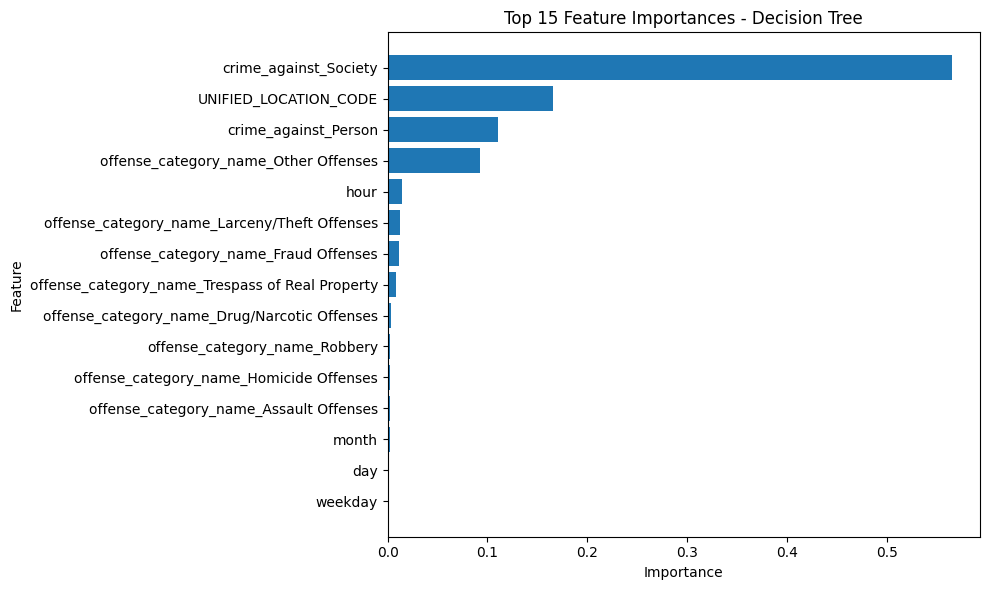

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': dt_model.feature_importances_
})


feature_importance_df = feature_importance_df.sort_values(
    by='importance',
    ascending=False
)

print(feature_importance_df.head(15))

top_n = 15
top_features = feature_importance_df.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(top_features['feature'][::-1], top_features['importance'][::-1])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Decision Tree")
plt.tight_layout()
plt.show()

The Decision Tree model mainly relies on crime type, especially crime_against, and location to determine whether an incident is likely to result in an arrest. Among the temporal features, only hour shows a noticeable effect, while the influence of the other time-related variables is relatively much weaker.

# 6.Spatial & Temporal accuracy evaluation

6.1Spatial accuracy evaluation

Model performance varies substantially across location types, indicating strong spatial heterogeneity in arrest predictability.

   UNIFIED_LOCATION_CODE   count  accuracy  precision    recall        f1
5                      6     571  0.807356   0.665289  0.847368  0.745370
1                      2  190388  0.848672   0.631967  0.792710  0.703270
3                      4   20121  0.547388   0.409821  0.915280  0.566147
8                      9    9349  0.900096   0.470990  0.637413  0.541708
6                      7    1594  0.774153   0.397778  0.667910  0.498607
2                      3    7079  0.767623   0.402516  0.603299  0.482867
9                     10  220226  0.842303   0.461231  0.505483  0.482344
4                      5    4069  0.730646   0.332410  0.784314  0.466926
7                      8    5562  0.882956   0.353612  0.374245  0.363636
0                      1   92189  0.776828   0.265446  0.505846  0.348181


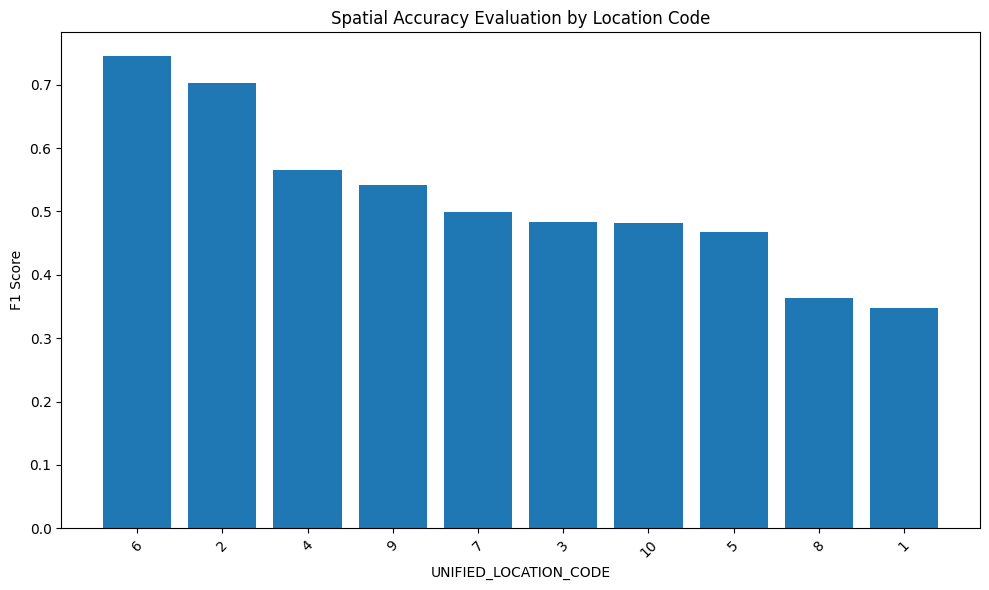

In [18]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import matplotlib.pyplot as plt

X_test_original = X.loc[X_test.index].copy()

spatial_eval_df = pd.DataFrame({
    'UNIFIED_LOCATION_CODE': X_test_original['UNIFIED_LOCATION_CODE'],
    'y_true': y_test,
    'y_pred': y_pred_dt
})

spatial_results = []

for loc_code, group in spatial_eval_df.groupby('UNIFIED_LOCATION_CODE'):
    if len(group) > 0:
        spatial_results.append({
            'UNIFIED_LOCATION_CODE': loc_code,
            'count': len(group),
            'accuracy': accuracy_score(group['y_true'], group['y_pred']),
            'precision': precision_score(group['y_true'], group['y_pred'], zero_division=0),
            'recall': recall_score(group['y_true'], group['y_pred'], zero_division=0),
            'f1': f1_score(group['y_true'], group['y_pred'], zero_division=0)
        })

spatial_results_df = pd.DataFrame(spatial_results)
spatial_results_df = spatial_results_df.sort_values(by='f1', ascending=False)

print(spatial_results_df)


plt.figure(figsize=(10, 6))
plt.bar(spatial_results_df['UNIFIED_LOCATION_CODE'].astype(str), spatial_results_df['f1'])
plt.xlabel("UNIFIED_LOCATION_CODE")
plt.ylabel("F1 Score")
plt.title("Spatial Accuracy Evaluation by Location Code")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

6 = Government/Public

2 = Street/Outdoor

4 = Retail/Commercial

9 = Parking Lot

7 = Medical Facility

3 = Transportation Hub

10 = Unknown/Other

5 = Entertainment

8 = Workplace/Office

1 = Residence

# 6.2Temporal accuracy evaluation

Arrest predictability follows clear time-of-day patterns, with weaker performance overnight and stronger performance during daytime and early evening.

    hour  count  accuracy  precision    recall        f1
0      0  33474  0.768328   0.341754  0.787291  0.476615
1      1  17118  0.655567   0.315318  0.817397  0.455083
2      2  15179  0.721391   0.318770  0.683901  0.434852
3      3  12645  0.733808   0.295023  0.650452  0.405930
4      4  10223  0.736770   0.259046  0.605055  0.362775
5      5   8822  0.821242   0.281481  0.450431  0.346457
6      6   9828  0.830484   0.373356  0.533933  0.439435
7      7  13513  0.875231   0.518692  0.446039  0.479630
8      8  19146  0.876528   0.546382  0.440313  0.487646
9      9  24487  0.889697   0.588408  0.503927  0.542901
10    10  24067  0.877010   0.683723  0.605833  0.642426
11    11  24751  0.870672   0.707841  0.641550  0.673067
12    12  32677  0.890137   0.660246  0.611089  0.634717
13    13  26028  0.874904   0.666515  0.621931  0.643452
14    14  27252  0.878137   0.645843  0.597714  0.620847
15    15  29935  0.872257   0.635460  0.569788  0.600835
16    16  29345  0.818027   0.5

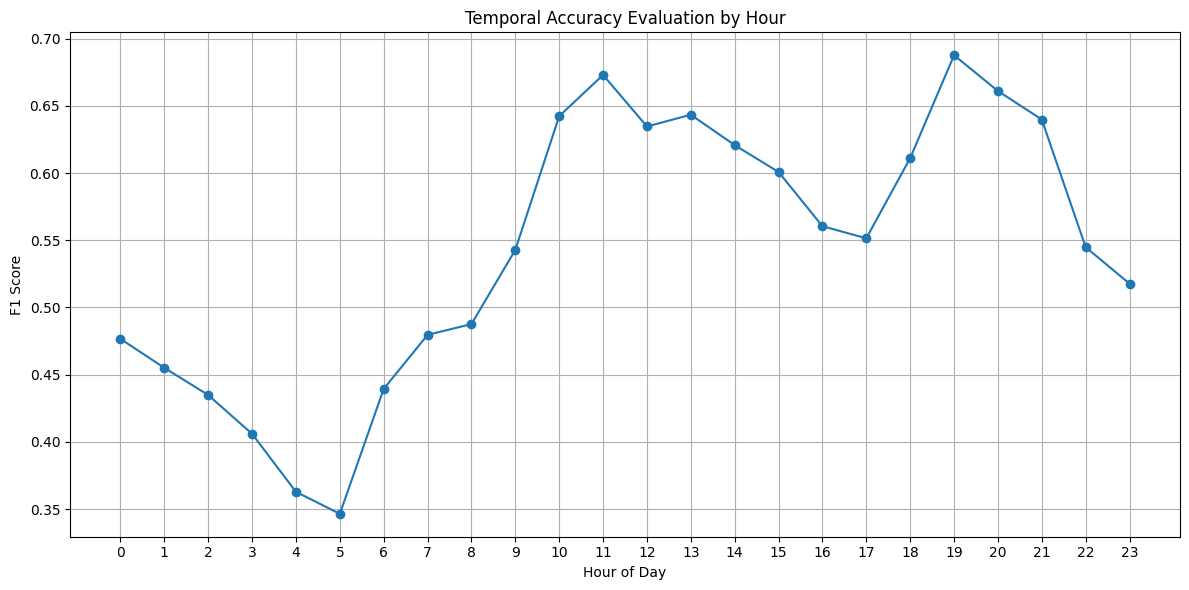

In [19]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import matplotlib.pyplot as plt

X_test_original = X.loc[X_test.index].copy()

temporal_eval_df = pd.DataFrame({
    'hour': X_test_original['hour'],
    'y_true': y_test,
    'y_pred': y_pred_dt
})

temporal_results = []

for hour, group in temporal_eval_df.groupby('hour'):
    if len(group) > 0:
        temporal_results.append({
            'hour': hour,
            'count': len(group),
            'accuracy': accuracy_score(group['y_true'], group['y_pred']),
            'precision': precision_score(group['y_true'], group['y_pred'], zero_division=0),
            'recall': recall_score(group['y_true'], group['y_pred'], zero_division=0),
            'f1': f1_score(group['y_true'], group['y_pred'], zero_division=0)
        })

temporal_results_df = pd.DataFrame(temporal_results)
temporal_results_df = temporal_results_df.sort_values(by='hour')

print(temporal_results_df)

plt.figure(figsize=(12, 6))
plt.plot(temporal_results_df['hour'], temporal_results_df['f1'], marker='o')
plt.xlabel("Hour of Day")
plt.ylabel("F1 Score")
plt.title("Temporal Accuracy Evaluation by Hour")
plt.xticks(range(24))
plt.grid(True)
plt.tight_layout()
plt.show()

1.The model performs worst in predicting arrest outcomes during the early morning hours, especially between 4:00 and 5:00, where the F1-score is the lowest.

2.After 9:00 a.m., the model performance improves noticeably, with a relatively stable high-performance period observed between 10:00 and 15:00.

3.The model performs well again during the evening hours from 18:00 to 21:00, with 19:00 showing the best performance of the entire day.

4.These results indicate that arrest patterns vary significantly across different time periods, and that hour provides meaningful predictive value for the model.

In [20]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

X_test_original = X.loc[X_test.index].copy()

weekend_eval_df = pd.DataFrame({
    'is_weekend': X_test_original['is_weekend'],
    'y_true': y_test,
    'y_pred': y_pred_dt
})

weekend_results = []

for weekend_flag, group in weekend_eval_df.groupby('is_weekend'):
    weekend_results.append({
        'is_weekend': weekend_flag,
        'count': len(group),
        'accuracy': accuracy_score(group['y_true'], group['y_pred']),
        'precision': precision_score(group['y_true'], group['y_pred'], zero_division=0),
        'recall': recall_score(group['y_true'], group['y_pred'], zero_division=0),
        'f1': f1_score(group['y_true'], group['y_pred'], zero_division=0)
    })

weekend_results_df = pd.DataFrame(weekend_results)

weekend_results_df['day_type'] = weekend_results_df['is_weekend'].map({
    0: 'Weekday',
    1: 'Weekend'
})

print(weekend_results_df[['day_type', 'count', 'accuracy', 'precision', 'recall', 'f1']])

  day_type   count  accuracy  precision    recall        f1
0  Weekday  393521  0.840687   0.535003  0.650112  0.586967
1  Weekend  157627  0.775901   0.417639  0.707437  0.525215


In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

dt_unbalanced = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

dt_unbalanced.fit(X_train, y_train)

y_pred_unbalanced = dt_unbalanced.predict(X_test)
y_prob_unbalanced = dt_unbalanced.predict_proba(X_test)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_unbalanced))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_unbalanced))

print("\nAUC-ROC:")
print(roc_auc_score(y_test, y_prob_unbalanced))

Confusion Matrix:
[[446096   8912]
 [ 53301  42839]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.98      0.93    455008
           1       0.83      0.45      0.58     96140

    accuracy                           0.89    551148
   macro avg       0.86      0.71      0.76    551148
weighted avg       0.88      0.89      0.87    551148


AUC-ROC:
0.8515404554188359


This experiment demonstrates that the Decision Tree model is highly sensitive to the class_weight setting. After removing balanced, the model becomes noticeably more conservative: Precision increases substantially, while Recall decreases sharply.

# 7.conclusion

7.1 Overall Model Comparison

In [23]:
import pandas as pd

final_model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting'
    ],
    'Accuracy': [0.77, 0.82, 0.82, 0.88],
    'Precision_1': [0.40, 0.49, 0.49, 0.83],
    'Recall_1': [0.65, 0.67, 0.66, 0.42],
    'F1_1': [0.49, 0.57, 0.57, 0.56],
    'AUC': [0.806, 0.852, 0.849, 0.847]
})

print(final_model_comparison)

best_model_summary = {
    "Selected Model": "Decision Tree (class_weight='balanced')",
    "Reason": "Best balance of Recall, F1-score, and AUC for predicting Arrest"
}

print(best_model_summary)

                 Model  Accuracy  Precision_1  Recall_1  F1_1    AUC
0  Logistic Regression      0.77         0.40      0.65  0.49  0.806
1        Decision Tree      0.82         0.49      0.67  0.57  0.852
2        Random Forest      0.82         0.49      0.66  0.57  0.849
3    Gradient Boosting      0.88         0.83      0.42  0.56  0.847
{'Selected Model': "Decision Tree (class_weight='balanced')", 'Reason': 'Best balance of Recall, F1-score, and AUC for predicting Arrest'}


Logistic Regression provided a useful baseline but was clearly weaker than the tree-based approaches. Decision Tree and Random Forest performed similarly, but Decision Tree achieved slightly better recall and AUC. Gradient Boosting achieved the highest accuracy and precision, but its recall was much lower, indicating that it was too conservative in identifying arrest cases. Therefore, Decision Tree was selected as the final model because it offered the most balanced performance for this task.

7.2 Feature Importance and Model Interpretation

Crime type is the most important predictor of arrest, followed by location, while time plays a secondary but still meaningful role.

Feature importance analysis based on the Decision Tree showed that the most influential variables were:

crime_against_Society

UNIFIED_LOCATION_CODE

crime_against_Person

offense_category_name_Other Offenses

hour

This indicates that crime type contributes the strongest signal to arrest prediction, especially the high-level crime_against categories. Location type is also highly informative, while temporal variables are less dominant overall. Among temporal variables, hour contributes the most useful predictive information.

In terms of spatial and temporal features, the model shows clear performance differences across location types. It performs more consistently in settings such as Street/Outdoor, while arrest prediction is more difficult in Residence locations. In addition, the predictability of arrest exhibits clear temporal patterns: the model performs more weakly during the early morning hours, but more strongly during daytime and early evening. At the same time, performance is generally more stable on weekdays, whereas weekends tend to produce higher recall at the cost of more false positives.

7.3 robustness

1.Cross-validation

The variation across the five folds is very small, indicating that the model is stable.

2.Balanced vs. unbalanced Decision Tree

The AUC remains almost unchanged, while the Precision–Recall trade-off changes significantly.

Therefore, the model shows relatively stable performance across different data splits, suggesting that it has a certain degree of robustness. At the same time, the class weight setting has a substantial impact on the balance between Precision and Recall, indicating that the model is quite sensitive to how class imbalance is handled.

7.4 limitations

The model has predictive value, but it is constrained by the limited scope of the available data.

This study has several limitations:

1.The model only uses location, time, and crime type variables, without access to factors such as police response time, patrol deployment, officer availability, witness information, or investigation progress.

2.Some spatial groups contain relatively small numbers of cases, so subgroup performance may be less stable.

3.The analysis is predictive rather than causal; it identifies statistical associations rather than direct causes of arrest outcomes.

4.The model should not be interpreted as making deterministic judgments about individual incidents.

Thus, the model is most useful for understanding data patterns rather than for high-stakes automated decision-making.